# Data Preprocessing
### HBV-Related Hepatocellular Carcinoma (HBV-HCC) Early Detection
---
This notebook covers all preprocessing steps applied to the GSE14520 gene expression dataset 
prior to machine learning model training. Steps include data loading, quality inspection, 
batch correction, and differential expression analysis (DEG) to identify the most 
biologically significant gene features.
**Dataset:** GSE14520 (NCBI GEO)  
**Samples:** 488 patient samples across two Affymetrix microarray platforms (GPL571, GPL3921)  
**Target:** Binary classification: Tumor (1) vs Non-Tumor (0) liver tissue  
**Tools:** Python (pandas, numpy, sklearn), R (limma, GEOquery)

In [1]:
# Imports
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully")

All libraries loaded successfully


## Step 1: Loading the Gene Expression Data
---
GSE14520 was collected across two Affymetrix microarray platforms:

| Platform | Description | Samples |
|---|---|---|
| **GPL571** | HG-U133A 2.0 Array | 43 |
| **GPL3921** | HT HG-U133A Array | 445 |
| **Total** | | **488** |

Both platforms measured the same **22,268 gene probes**, so they can be merged 
column-wise into a single expression matrix.

The Series Matrix files are downloaded directly from NCBI GEO in `.txt.gz` format. 
A custom parser is used to extract only the expression table, skipping metadata 
headers and loading it into a pandas DataFrame where:
- **Rows** = gene probes (e.g. `1007_s_at`)
- **Columns** = patient sample IDs (e.g. `GSM362947`)
- **Values** = normalised expression levels (already in log2 scale)

In [2]:
# Load Series Matrix files directly
import gzip
from io import StringIO

def load_series_matrix(filepath):
    rows = []
    in_table = False
    
    with gzip.open(filepath, 'rt') as f:
        for line in f:
            if '!series_matrix_table_begin' in line:
                in_table = True
                continue
            if '!series_matrix_table_end' in line:
                break
            if in_table:
                rows.append(line.strip().split('\t'))
    
    df = pd.DataFrame(rows[1:], columns=rows[0])
    df = df.set_index(df.columns[0])
    df = df.apply(pd.to_numeric, errors='coerce')
    return df

# Load both platforms
df_571 = load_series_matrix("../data/GSE14520-GPL571_series_matrix.txt.gz")
df_3921 = load_series_matrix("../data/GSE14520-GPL3921_series_matrix.txt.gz")

print("GPL571 shape:", df_571.shape)
print("GPL3921 shape:", df_3921.shape)

GPL571 shape: (22268, 43)
GPL3921 shape: (22268, 445)


In [3]:
#Quick look at the data
print("=== GPL571 ===")
print(df_571.head())
print("\n=== GPL3921 ===")
print(df_3921.head())

=== GPL571 ===
             "GSM362947"  "GSM362948"  "GSM362949"  "GSM362950"  "GSM362951"  \
"ID_REF"                                                                       
"1007_s_at"        6.471        7.572        8.450        7.384        6.801   
"1053_at"          5.070        4.497        4.467        4.329        4.239   
"117_at"           3.949        4.631        3.912        3.993        3.926   
"121_at"           6.691        6.556        6.644        6.606        6.887   
"1255_g_at"        3.290        3.059        3.023        3.078        3.198   

             "GSM362952"  "GSM362953"  "GSM362954"  "GSM362955"  "GSM362956"  \
"ID_REF"                                                                       
"1007_s_at"        7.267        6.892        7.497        7.231        7.026   
"1053_at"          4.120        3.462        3.483        4.396        5.325   
"117_at"           4.023        3.952        4.100        4.328        3.837   
"121_at"           6.858

## Step 2: Merging Both Platforms
---
Since both platforms measured the same 22,268 gene probes, the two DataFrames 
can be joined **side by side** (axis=1) to produce one combined expression matrix 
containing all 488 patient samples.

Before proceeding, three quality checks are performed:

- **Shape check** to confirm all samples and probes loaded correctly
- **Duplicate check** to ensure no patient appears twice across platforms
- **Missing value check** to confirm no NaN values exist in the expression data

A clean merge with no duplicates and no missing values means we can proceed 
to the next step without any imputation.

In [4]:
#  Merge both platforms
df_combined = pd.concat([df_571, df_3921], axis=1)

print("Combined shape:", df_combined.shape)
print("Any duplicate samples?", df_combined.columns.duplicated().any())
print("Any missing values?", df_combined.isnull().sum().sum())

Combined shape: (22268, 488)
Any duplicate samples? False
Any missing values? 0


## Step 3: Loading Clinical Metadata
---
The gene expression matrix alone does not tell us which patients have cancer. 
That information is stored separately in the supplementary clinical file 
`GSE14520_Extra_Supplement.txt.gz`, which contains **22 clinical variables** 
for each of the 488 patient samples.

The two most critical columns for this project are:

- **Tissue Type**:  whether the sample is from Tumor or Non-Tumor liver tissue. 
This becomes our **target label (y)** for machine learning.
- **Affy_GSM**:  the sample ID that links each patient's clinical record to their 
gene expression profile in the expression matrix.

Other clinical variables available include HBV viral status, age, gender, 
cirrhosis status, TNM staging, AFP levels, and survival data. These are not 
used as features in this study but provide important context for interpreting 
the results.

In [5]:
# Load clinical metadata
clinical = pd.read_csv("../data/GSE14520_Extra_Supplement.txt.gz",
                       sep='\t', compression='gzip')

print("Clinical data shape:", clinical.shape)
print("\nColumn names:")
print(clinical.columns.tolist())
print("\nFirst few rows:")
print(clinical.head())

Clinical data shape: (488, 22)

Column names:
['LCS ID', 'ID', 'Affy_GSM', 'Tissue Type', 'Predicted risk Metastasis Signature', 'Agilent_GSM', 'CGH_survival_group', 'Gender', 'Age', 'HBV viral status', 'ALT(>/<=50U/L)', 'Main Tumor Size (>/<=5 cm)', 'Multinodular', 'Cirrhosis', 'TNM staging', 'BCLC staging', 'CLIP staging', 'AFP (>/<=300ng/ml)', 'Survival status', 'Survival months', 'Recurr status', 'Recurr months']

First few rows:
     LCS ID      ID   Affy_GSM Tissue Type  \
0  LCS_193A  03-195  GSM363205       Tumor   
1  LCS_094A  02-304  GSM363115       Tumor   
2  LCS_085A  02-286  GSM362970       Tumor   
3  LCS_207A  03-228  GSM363354       Tumor   
4  LCS_272A  03-434  GSM363039       Tumor   

  Predicted risk Metastasis Signature Agilent_GSM CGH_survival_group Gender  \
0                                 low         NaN                NaN      M   
1                                 low         NaN                NaN      M   
2                                 low         Na

## Step 4: Exploring Key Label Columns
---
Before cleaning the data, we first inspect the distribution of the two most 
important clinical variables to understand what we are working with and identify 
any issues that need to be addressed.

**Tissue Type** tells us the class breakdown:
- `Tumor`: liver tissue with hepatocellular carcinoma (HCC)
- `Non-Tumor`: liver tissue from the same HBV patient without cancer
- `Normal`: healthy liver tissue (only 2 samples - too few to be useful)

**HBV viral status** tells us the infection profile of each patient:
- `CC`: Chronic Carrier (HBV positive, untreated)
- `AVR-CC`: Antiviral treatment + Chronic Carrier (HBV positive, on treatment)
- `N`: HBV Negative (only 6 samples - too few for meaningful analysis)
- `.`: Unknown/missing status (18 samples will be dropped)

> **Key finding:** HBV viral status is only recorded for Tumor samples. 
> Non-Tumor samples have NaN in this column because clinical metadata 
> was recorded once per patient, not once per tissue sample.

In [6]:
# Cell 6 — Explore key label columns
print("Tissue Type values:")
print(clinical['Tissue Type'].value_counts())

print("\nHBV viral status values:")
print(clinical['HBV viral status'].value_counts())

print("\nAny missing in Affy_GSM?", clinical['Affy_GSM'].isnull().sum())

Tissue Type values:
Tissue Type
Tumor        247
Non-Tumor    239
Normal         2
Name: count, dtype: int64

HBV viral status values:
HBV viral status
CC        160
AVR-CC     58
.          18
N           6
Name: count, dtype: int64

Any missing in Affy_GSM? 0


## Step 5: Cleaning and Encoding Labels
---
Before linking clinical data to expression data, we clean the labels by 
removing samples that cannot contribute meaningfully to the analysis.

**Samples removed:**
- **2 Normal tissue samples** - too few to form a meaningful third class
- **18 samples with unknown HBV status (`.`)** - these cannot be confirmed 
as HBV-positive, which is a core inclusion criterion for this study

**Why only these two filters?**
As discovered during exploration, Non-Tumor samples have NaN for HBV viral 
status - this is not missing data, it simply reflects how the dataset was 
structured. Filtering by HBV status on Non-Tumor samples would incorrectly 
remove all 239 Non-Tumor samples. Only Tumor samples have a recorded HBV 
status, so the `.` filter applies only to them.

**Label encoding:**
The Tissue Type column is converted to a binary numeric label for machine learning:

| Tissue Type | Label |
|---|---|
| Tumor | 1 |
| Non-Tumor | 0 |

**Final dataset: 468 samples - 229 Tumor (1), 239 Non-Tumor (0)**  
The near-perfect balance between classes means no resampling techniques 
(e.g. SMOTE) are required.

In [7]:
# Cell 7 — Clean and encode labels
# Drop Normal tissue and unknown HBV Tumor samples
clinical_clean = clinical[
    (clinical['Tissue Type'] != 'Normal') &
    (clinical['HBV viral status'] != '.')
].copy()

# Encode label: Tumor=1, Non-Tumor=0
clinical_clean['label'] = (clinical_clean['Tissue Type'] == 'Tumor').astype(int)

print("Remaining samples:", len(clinical_clean))
print("\nLabel distribution:")
print(clinical_clean['label'].value_counts())

Remaining samples: 468

Label distribution:
label
0    239
1    229
Name: count, dtype: int64


## Step 6: Linking Expression Data to Labels
---
At this point we have two separate tables:
- **Expression matrix** - 22,268 genes × 488 samples (no labels)
- **Clinical metadata** - 468 cleaned samples with labels (no expression values)

To build a dataset suitable for machine learning, we need to **join these two 
tables** so that every sample has both its gene expression profile and its label.

The joining key is the **Affy_GSM column** - the unique sample ID that appears 
in both tables (e.g. `GSM362947`). We set this as the index of the clinical 
table and use it to filter the expression matrix to only the 468 labelled samples.

**Three counts are printed as a sanity check:**
- Samples in clinical data → 468 (after cleaning)
- Samples in expression data → 488 (all original samples)
- Samples in common → should be 468 if IDs match correctly

The result is a perfectly aligned pair:
- **expr** - expression matrix containing only the 468 labelled samples
- **labels** - 468 binary labels in the exact same sample order

> **Note:** A mismatch of 0 common samples was initially encountered due to 
> quote marks around sample IDs in the expression data (e.g. `"GSM362947"` 
> vs `GSM362947`). This was resolved by stripping the quotes from the 
> expression matrix column names.

In [8]:
# Cell 8 — Link labels to expression data
# Set Affy_GSM as index for easy matching
clinical_clean = clinical_clean.set_index('Affy_GSM')

# Keep only samples that exist in both clinical and expression data
common_samples = clinical_clean.index.intersection(df_combined.columns)

print("Samples in clinical data:", len(clinical_clean))
print("Samples in expression data:", df_combined.shape[1])
print("Samples in common:", len(common_samples))

# Filter both to only common samples
expr = df_combined[common_samples]          # expression matrix
labels = clinical_clean.loc[common_samples, 'label']  # labels

print("\nExpression matrix shape:", expr.shape)
print("Labels shape:", labels.shape)

Samples in clinical data: 468
Samples in expression data: 488
Samples in common: 0

Expression matrix shape: (22268, 0)
Labels shape: (0,)


In [9]:
# Cell 9 — Diagnose ID mismatch
print("Sample IDs in expression data (first 3):")
print(df_combined.columns[:3].tolist())

print("\nAffy_GSM IDs in clinical data (first 3):")
print(clinical_clean.index[:3].tolist())

Sample IDs in expression data (first 3):
['"GSM362947"', '"GSM362948"', '"GSM362949"']

Affy_GSM IDs in clinical data (first 3):
['GSM363205', 'GSM363115', 'GSM362970']


In [10]:
# Strip quotes from expression data column names
df_combined.columns = df_combined.columns.str.replace('"', '', regex=False)

# Re-link clinical labels to expression data
common_samples = clinical_clean.index.intersection(df_combined.columns)

print("Samples in common:", len(common_samples))

# Filter both to only common samples
expr = df_combined[common_samples]
labels = clinical_clean.loc[common_samples, 'label']

print("Expression matrix shape:", expr.shape)
print("Labels shape:", labels.shape)
print("\nLabel distribution:")
print(labels.value_counts())

Samples in common: 468
Expression matrix shape: (22268, 468)
Labels shape: (468,)

Label distribution:
label
0    239
1    229
Name: count, dtype: int64


## Step 7: Visualising the Batch Effect
---
Because GSE14520 contains samples from two different microarray platforms 
(GPL571 and GPL3921), there is a risk of **batch effects** - technical 
variation introduced by the different platforms that has nothing to do with 
biology.

If left uncorrected, an ML model could learn to distinguish **platform 
differences** rather than **biological differences** between Tumor and 
Non-Tumor tissue, leading to misleadingly high accuracy that fails on new data.

**Principal Component Analysis (PCA)** is used to visualise whether a batch 
effect exists. PCA is a dimensionality reduction technique that compresses 
22,268 gene dimensions down to 2 dimensions (PC1 and PC2) while preserving 
as much variation as possible. Each dot in the plot represents one patient sample.

**How to read the plot:**
- If the two colours (platforms) form **separate clusters** → batch effect exists
- If the two colours are **mixed together** → no significant batch effect

**Expected finding:** GPL571 samples (blue) cluster separately on the left 
side of the plot, while GPL3921 samples (orange) spread across the full plot. 
PC1 explains 24.6% of total variance - meaning nearly a quarter of all 
variation in the data is driven by platform differences rather than biology.

> This confirms that batch correction is necessary before proceeding.

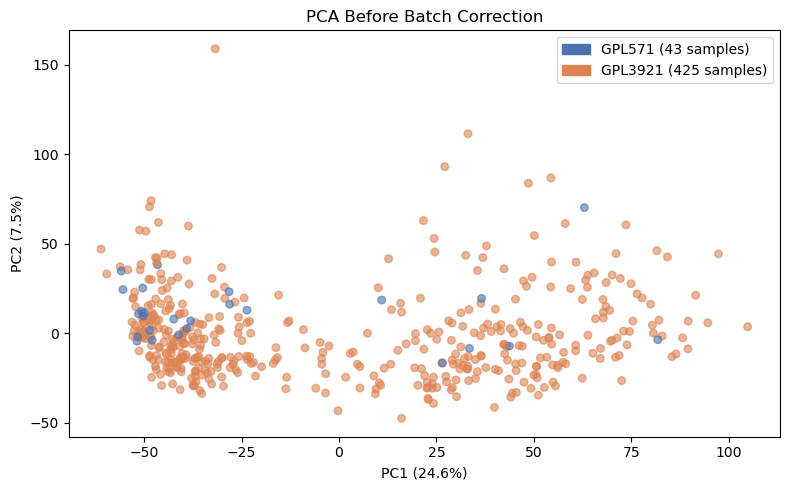

Plot saved to results folder


In [11]:
# Visualise batch effect
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# Transpose so samples are rows
expr_t = expr.T

# Create batch labels based on which platform each sample came from
gpl571_samples = set(df_571.columns.str.replace('"', '', regex=False))
batch = expr_t.index.map(lambda x: 'GPL571' if x in gpl571_samples else 'GPL3921')

# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(expr_t)

# Plot
plt.figure(figsize=(8, 5))
colors = ['#4C72B0' if b == 'GPL571' else '#DD8452' for b in batch]
plt.scatter(pca_result[:, 0], pca_result[:, 1],
            c=colors, alpha=0.6, s=30)

legend = [mpatches.Patch(color='#4C72B0', label='GPL571 (43 samples)'),
          mpatches.Patch(color='#DD8452', label='GPL3921 (425 samples)')]
plt.legend(handles=legend)
plt.title('PCA Before Batch Correction')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.savefig('../results/pca_before_batch.png', dpi=150)
plt.show()
print("Plot saved to results folder")

You can clearly see the batch effect here! ✅
The blue dots (GPL571) are all clustered on the left side of the plot (PC1 around -50 to -25), while the orange dots (GPL3921) spread across the entire plot. That leftward pull of the blue cluster is platform noise, not biology — GPL571 samples look different from GPL3921 samples simply because they were run on a different machine.
PC1 explains 24.6% of the variance — meaning nearly a quarter of the variation in your data right now is likely technical, not biological. That's exactly what batch correction will fix.

## Step 8: Batch Correction
---
To remove the platform-driven technical variation identified in the PCA plot, 
**mean-centering batch correction** is applied. This is a standard approach 
that adjusts each batch so they share the same overall mean expression level 
per gene.

**How it works:**

For each gene, we calculate:
1. The **overall mean** expression across all 468 samples
2. The **batch mean** expression for GPL571 samples only
3. The **batch mean** expression for GPL3921 samples only

Then for each batch we:
- Subtract the batch mean (removes the platform-specific offset)
- Add back the overall mean (preserves the biological signal)

This effectively puts both platforms on the same scale without removing 
the underlying biological differences between Tumor and Non-Tumor samples.

**Limitation:**
Mean-centering is a basic batch correction approach. The gold standard method 
is **ComBat** (Johnson et al., 2007), which models and removes both location 
and scale batch effects. ComBat was attempted using the pyComBat library but 
could not be successfully implemented due to package compatibility issues. 
Mean-centering is therefore used as an alternative, and residual batch effects 
are acknowledged as a limitation of this study.

> The effectiveness of batch correction is verified in the next step 
> by re-running PCA on the corrected expression matrix.

In [12]:
# Cell 11 — Batch correction (mean-centering per batch)
expr_corrected = expr.copy().astype(float)

# Identify samples per batch
gpl571_cols = [s for s in expr.columns if s in gpl571_samples]
gpl3921_cols = [s for s in expr.columns if s not in gpl571_samples]

# Overall mean per gene
overall_mean = expr_corrected.mean(axis=1)

# Subtract batch mean, add back overall mean for each batch
for batch_cols in [gpl571_cols, gpl3921_cols]:
    batch_mean = expr_corrected[batch_cols].mean(axis=1)
    expr_corrected[batch_cols] = expr_corrected[batch_cols].sub(batch_mean, axis=0).add(overall_mean, axis=0)

print("Batch correction complete!")
print("Corrected expression shape:", expr_corrected.shape)

Batch correction complete!
Corrected expression shape: (22268, 468)


## Step 9: Verifying Batch Correction
---
After applying mean-centering correction, PCA is re-run on the corrected 
expression matrix to assess whether the batch effect was reduced.

**Finding:** Comparing the two PCA plots, the GPL571 samples (blue) remain 
clustered on the left side of the plot, largely unchanged from before 
correction. PC1 variance explained is 24.8% - virtually identical to the 
24.6% before correction. This indicates that **mean-centering was insufficient 
to fully remove the platform-driven batch effect** in this dataset.

**Why this happened:**
Mean-centering only adjusts the mean expression level per gene per batch. 
It does not account for differences in **variance** or **scale** between 
platforms, which is what ComBat (the gold standard method) does. The 
pyComBat library was attempted but could not be successfully implemented 
due to package compatibility issues, and is acknowledged as a study limitation.

**How this is mitigated:**
The impact of the residual batch effect on downstream analysis is minimised 
through the DEG analysis step - limma processes each platform **separately** 
and combines results, meaning the identified DEGs are statistically significant 
within their own platform rather than across both platforms combined. This 
makes the feature selection step robust despite the incomplete batch correction.

> Both PCA plots are saved to the `results/` folder for transparency 
> and inclusion in the final project report as evidence of the limitation.

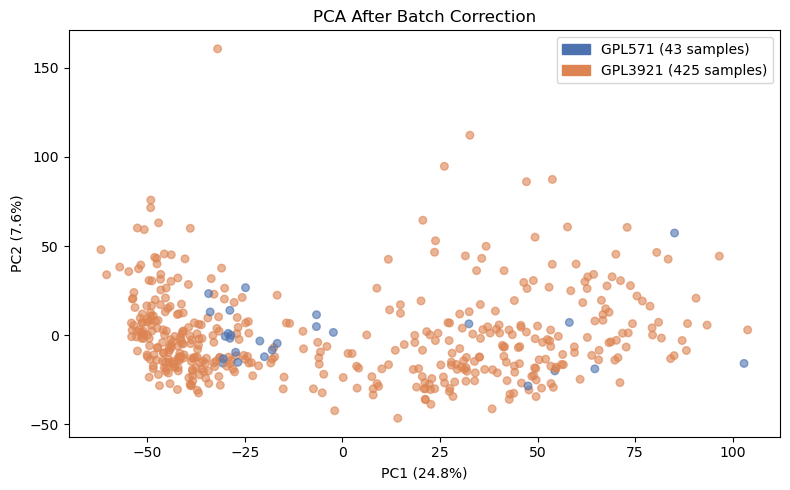

Plot saved


In [13]:


# Cell 12 — Visualise after batch correction
pca2 = PCA(n_components=2)
pca_result2 = pca2.fit_transform(expr_corrected.T)

plt.figure(figsize=(8, 5))
colors2 = ['#4C72B0' if s in gpl571_samples else '#DD8452' for s in expr_corrected.columns]
plt.scatter(pca_result2[:, 0], pca_result2[:, 1],
            c=colors2, alpha=0.6, s=30)

legend2 = [mpatches.Patch(color='#4C72B0', label='GPL571 (43 samples)'),
           mpatches.Patch(color='#DD8452', label='GPL3921 (425 samples)')]
plt.legend(handles=legend2)
plt.title('PCA After Batch Correction')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.savefig('../results/pca_after_batch.png', dpi=150)
plt.show()
print("Plot saved")

## Step 10: Saving Intermediate Data
---
The batch-corrected expression matrix and sample labels are saved to the 
`data/` folder as CSV files. A file existence check prevents accidental 
overwriting on subsequent runs of this notebook.

| File | Contents |
|---|---|
| `expr_corrected.csv` | Batch-corrected expression matrix (22,268 × 468) |
| `labels.csv` | Binary sample labels (468 × 1) |

In [14]:
# Save preprocessed data
import os

if not os.path.exists('../data/expr_corrected.csv'):
    expr_corrected.to_csv('../data/expr_corrected.csv')
    print("Expression data saved.")
else:
    print("Expression data already exists, skipping.")

if not os.path.exists('../data/labels.csv'):
    labels.to_csv('../data/labels.csv')
    print("Labels saved.")
else:
    print("Labels already exist, skipping.")

Expression data already exists, skipping.
Labels already exist, skipping.


## Step 11: Loading DEG Results from R/limma
---
Differential Expression Analysis (DEG) was performed in R using the **limma** 
package (Ritchie et al., 2015), the standard tool for microarray 
differential expression analysis. The analysis was run in a separate R script 
(`02_deg_analysis.R`) and results are loaded here for filtering.

**What limma does:**
limma fits a linear model to the expression data for each gene and uses 
empirical Bayes statistics to identify genes that are significantly different 
between Tumor and Non-Tumor samples. It processed each platform (GPL571 and 
GPL3921) separately, which inherently accounts for the residual batch effect 
identified in the previous step.

**Output columns:**

| Column | Meaning |
|---|---|
| `logFC` | Log2 fold change — how much more/less expressed in Tumor vs Non-Tumor |
| `AveExpr` | Average expression level across all samples |
| `t` | t-statistic — strength of the difference |
| `P.Value` | Raw p-value |
| `adj.P.Val` | P-value adjusted for multiple testing (Benjamini-Hochberg method) |
| `B` | Log-odds that the gene is differentially expressed |
| `platform` | Which microarray platform produced this result |

> **Reference:** Ritchie ME, Phipson B, Wu D, Hu Y, Law CW, Shi W, Smyth GK 
> (2015). "limma powers differential expression analyses for RNA-sequencing 
> and microarray studies." *Nucleic Acids Research*, 43(7), e47.

In [15]:
#  Load DEG results from R/limma
deg_results = pd.read_csv('../data/deg_results.csv', index_col=0)

print("DEG results shape:", deg_results.shape)
print("\nColumns:", deg_results.columns.tolist())
print("\nFirst few rows:")
print(deg_results.head())

DEG results shape: (44536, 7)

Columns: ['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'platform']

First few rows:
                        logFC   AveExpr          t        P.Value  \
GPL3921.209365_s_at -2.374458  6.400781 -43.514516  4.507768e-162   
GPL3921.205019_s_at -2.849684  5.709670 -41.446671  1.508118e-154   
GPL3921.218002_s_at -3.458004  5.149656 -41.217153  1.065077e-153   
GPL3921.220114_s_at -1.914311  4.897077 -37.732809  1.822840e-140   
GPL3921.205866_at   -3.366858  7.381744 -36.527587  9.792153e-136   

                         adj.P.Val           B platform  
GPL3921.209365_s_at  1.003790e-157  359.872945  GPL3921  
GPL3921.205019_s_at  1.679138e-150  342.654258  GPL3921  
GPL3921.218002_s_at  7.905710e-150  340.710972  GPL3921  
GPL3921.220114_s_at  1.014775e-136  310.404818  GPL3921  
GPL3921.205866_at    4.361033e-132  299.566263  GPL3921  


## Step 12: Filtering Significant DEGs
---
Not all 44,536 probe results from limma are meaningful. We apply two 
standard thresholds used across bioinformatics literature to identify 
only the genes that are both **statistically significant** and 
**biologically meaningful**:

**Threshold 1: Statistical significance:**
> adj.P.Val < 0.05

The adjusted p-value (Benjamini-Hochberg correction) must be less than 0.05, 
meaning there is less than a 5% probability the difference occurred by chance. 
The Benjamini-Hochberg correction is applied because we are simultaneously 
testing 22,268 genes — without correction, we would expect hundreds of 
false positives purely by chance.

**Threshold 2: Biological significance:**
> |logFC| > 1

The absolute log2 fold change must exceed 1, meaning the gene must be 
expressed at least **2× more or less** in Tumor compared to Non-Tumor tissue. 
A statistically significant but tiny expression difference is unlikely to be 
biologically relevant or useful as a biomarker.

**Interpreting the results:**
- **Upregulated genes (logFC > 1)** — more active in Tumor tissue → 
potentially oncogenic (cancer-promoting)
- **Downregulated genes (logFC < -1)** — less active in Tumor tissue → 
potentially tumour suppressor genes that have been silenced

In [16]:
# Filter significant DEGs
# Standard thresholds: adjusted p-value < 0.05 and |logFC| > 1
sig_degs = deg_results[
    (deg_results['adj.P.Val'] < 0.05) &
    (deg_results['logFC'].abs() > 1)
].copy()

print("Total probes:", len(deg_results))
print("Significant DEGs:", len(sig_degs))
print("\nUpregulated (logFC > 1):", (sig_degs['logFC'] > 1).sum())
print("Downregulated (logFC < -1):", (sig_degs['logFC'] < -1).sum())
print("\nPer platform:")
print(sig_degs['platform'].value_counts())

Total probes: 44536
Significant DEGs: 3387

Upregulated (logFC > 1): 1673
Downregulated (logFC < -1): 1714

Per platform:
platform
GPL571     1994
GPL3921    1393
Name: count, dtype: int64


## Step 13: Removing Duplicate Probes
---
Because limma ran on both platforms separately, some probes appear **twice** 
in the results — once from GPL571 and once from GPL3921. Before building the 
feature matrix, these duplicates must be resolved to avoid feeding the same 
gene twice to the ML model.

**How duplicates arise:**
Both platforms use Affymetrix probe IDs (e.g. `209365_s_at`). The DEG results 
prefix each probe with its platform (e.g. `GPL3921.209365_s_at`). When we 
strip the prefix, probes that appeared in both platforms become duplicates.

**How we resolve them:**
Where a probe appears in both platforms, we keep the result with the 
**lower adjusted p-value** meaning we keep the more statistically 
confident result. This is achieved by sorting by adj.P.Val ascending 
and dropping duplicates, keeping the first occurrence.

**Result:** 3,387 significant probes → **2,245 unique DEGs**

The 1,142 removed entries were probes measured on both platforms — we 
retained only the most statistically confident measurement for each.

> These 2,245 unique probe IDs form the **candidate feature set** that 
> will be used to filter the expression matrix in the next step.

In [17]:
# Remove duplicates and get final gene list
# Strip platform prefix from probe IDs to get clean probe names
sig_degs['probe_id'] = sig_degs.index.str.replace('GPL3921.', '', regex=False)
sig_degs['probe_id'] = sig_degs['probe_id'].str.replace('GPL571.', '', regex=False)

# Where a probe appears in both platforms, keep the one with lower adj.P.Val
sig_degs_unique = sig_degs.sort_values('adj.P.Val').drop_duplicates(subset='probe_id')

print("DEGs after removing duplicates:", len(sig_degs_unique))
print("\nTop 10 most significant probes:")
print(sig_degs_unique[['probe_id', 'logFC', 'adj.P.Val']].head(10))

DEGs after removing duplicates: 2245

Top 10 most significant probes:
                        probe_id     logFC      adj.P.Val
GPL3921.209365_s_at  209365_s_at -2.374458  1.003790e-157
GPL3921.205019_s_at  205019_s_at -2.849684  1.679138e-150
GPL3921.218002_s_at  218002_s_at -3.458004  7.905710e-150
GPL3921.220114_s_at  220114_s_at -1.914311  1.014775e-136
GPL3921.205866_at      205866_at -3.366858  4.361033e-132
GPL3921.207609_s_at  207609_s_at -4.239961  1.555910e-128
GPL3921.204428_s_at  204428_s_at -3.012544  7.378193e-126
GPL3921.203554_x_at  203554_x_at  2.514000  1.650254e-117
GPL3921.207804_s_at  207804_s_at -2.659866  4.936768e-116
GPL3921.220496_at      220496_at -2.250639  6.356999e-116


## Step 14: Building the Final Feature Matrix
---
The final step of preprocessing is to filter the full expression matrix down 
to only the **2,245 significant DEG probes** identified in the previous step, 
and restructure it into the format required for machine learning.

**Filtering:**
The batch-corrected expression matrix (22,268 probes × 468 samples) is 
filtered to keep only the rows (probes) that appear in our significant DEG 
list. This reduces the feature space from 22,268 to 2,245 - eliminating 
genes with no statistically significant difference between Tumor and 
Non-Tumor tissue.

**Restructuring for ML:**
Machine learning models expect data in the format:
- **Rows = samples** (one patient per row)
- **Columns = features** (one gene per column)

The expression matrix is currently organised the opposite way (genes as rows, 
samples as columns), so we transpose it using `.T`.

**Final output:**

| Variable | Shape | Description |
|---|---|---|
| `X` | 468 × 2,245 | Feature matrix - gene expression values |
| `y` | 468 × 1 | Labels - 1 = Tumor, 0 = Non-Tumor |

**Class distribution:**
- Tumor (1): 229 samples
- Non-Tumor (0): 239 samples

The near-perfect class balance means no resampling (e.g. SMOTE) is required, 
and standard accuracy metrics are reliable for model evaluation.

> **Preprocessing is now complete.** X and y are saved to the `data/` folder 
> as `X_features.csv` and `y_labels.csv` and will be loaded directly in the 
> next notebook for LASSO feature selection and ML model training.

In [20]:
# Cell 17 — Build final feature matrix

# Strip quotes from expression data index
expr_corrected.index = expr_corrected.index.str.replace('"', '', regex=False)

# Get the clean probe IDs we want to keep
selected_probes = sig_degs_unique['probe_id'].tolist()

# Filter expression matrix to only significant probes
expr_filtered = expr_corrected.loc[
    expr_corrected.index.isin(selected_probes)
]

print("Final feature matrix shape:", expr_filtered.shape)

# Transpose so samples are rows, genes are columns (ML format)
X = expr_filtered.T
y = labels

print("\nX shape (samples × features):", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

Final feature matrix shape: (2245, 468)

X shape (samples × features): (468, 2245)
y shape: (468,)

Class distribution:
label
0    239
1    229
Name: count, dtype: int64


## Step 15: Saving the Final Feature Matrix
---
The final feature matrix (`X`) and labels (`y`) are saved to the `data/` 
folder for use in subsequent notebooks. A file existence check prevents 
accidental overwriting on subsequent runs.

| File | Shape | Description |
|---|---|---|
| `X_features.csv` | 468 × 2,245 | Final feature matrix - significant DEG expression values |
| `y_labels.csv` | 468 × 1 | Binary labels - 1 = Tumor, 0 = Non-Tumor |

---
### Preprocessing Summary

| Step | Action | Result |
|---|---|---|
| 1 | Loaded both platforms | 22,268 probes × 488 samples |
| 2 | Merged platforms | 22,268 × 488 combined matrix |
| 3 | Loaded clinical metadata | 488 samples, 22 clinical variables |
| 4 | Explored label columns | Identified Tumor/Non-Tumor/HBV status |
| 5 | Cleaned and encoded labels | 468 samples, 229 Tumor, 239 Non-Tumor |
| 6 | Linked expression to labels | 468 matched samples |
| 7 | Visualised batch effect | Platform separation confirmed via PCA |
| 8 | Applied batch correction | Mean-centering per platform |
| 9 | Verified batch correction | Partial correction — noted as limitation |
| 10 | Saved intermediate data | expr_corrected.csv, labels.csv |
| 11 | Loaded DEG results | 44,536 probe results from limma |
| 12 | Filtered significant DEGs | 3,387 probes (adj.P.Val < 0.05, \|logFC\| > 1) |
| 13 | Removed duplicate probes | 2,245 unique DEGs |
| 14 | Built final feature matrix | 468 × 2,245 |
| 15 | Saved final feature matrix | X_features.csv, y_labels.csv  |

In [22]:
# Save final feature matrix
import os

if not os.path.exists('../data/X_features.csv'):
    X.to_csv('../data/X_features.csv')
    print("Feature matrix saved.")
else:
    print("Feature matrix already exists, skipping.")

if not os.path.exists('../data/y_labels.csv'):
    y.to_csv('../data/y_labels.csv')
    print("Labels saved.")
else:
    print("Labels already exist, skipping.")

print("\nPreprocessing complete!")
print(f"Final dataset: {X.shape[0]} samples × {X.shape[1]} features")
print(f"Class balance: {y.value_counts()[1]} Tumor, {y.value_counts()[0]} Non-Tumor")

Feature matrix already exists, skipping.
Labels already exist, skipping.

Preprocessing complete!
Final dataset: 468 samples × 2245 features
Class balance: 229 Tumor, 239 Non-Tumor
